# Model Evaluation Notebook

This notebook evaluates the performance of multiple machine learning models trained to predict customer churn.  
Because churn events are relatively rare, the target variable is **highly imbalanced**, which makes traditional accuracy-based evaluation misleading. Instead, this notebook focuses on metrics and visualizations that are more appropriate for imbalanced classification.

In [49]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
%matplotlib inline
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, precision_recall_curve, average_precision_score
)

## 1. Load Data

In [50]:
df = pd.read_csv("../data/PreprocessedData.csv").copy()

## 2. Train/Test split

In [51]:
y = df["Churn"]
X = df.drop("Churn", axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=22, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=22, stratify=y_train)

## 3. Load Models & Thresholds

In [52]:
lr_model = joblib.load("../models/logreg_best_model.pkl")
rf_model = joblib.load("../models/rf_best_model.pkl")
xgb_model = joblib.load("../models/xgb_best_model.pkl")

In [53]:
lr_threshold = joblib.load("../models/logreg_best_threshold.pkl")
rf_threshold = joblib.load("../models/rf_best_threshold.pkl")
xgb_threshold = joblib.load("../models/xgb_best_threshold.pkl")

## 4. Evalution Function 

In [54]:
def evaluate(model, X_test, y_test, y_proba):
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    return {
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba)
    }

In [55]:
def evaluate_threshold(y_true, y_pred, y_proba):
    return {
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba)
    }

## 5. Evaluate on Test set

### 5.1 Default Threshold
This shows how the models behave without any threshold tuning.  
Default thresholds typically produce **higher precision but lower recall** in imbalanced datasets.

In [56]:
results = {}

In [57]:
#Logistic Regression
proba_lr = lr_model.predict_proba(X_test)[:, 1]


#Random Forest
proba_rf = rf_model.predict_proba(X_test)[:, 1]


#XGBoost
proba_xgb = xgb_model.predict_proba(X_test)[:, 1]


In [58]:
#Logistic Regression
results["log_reg_def"] = evaluate(lr_model, X_test, y_test, proba_lr)

#Random Forest
results["ran_for_def"] = evaluate(rf_model, X_test, y_test, proba_rf)

#XGBoost
results["XGBoost_def"] = evaluate(xgb_model, X_test, y_test, proba_xgb)

### 5.2 Optimized Threshold
We apply the tuned thresholds learned from the validation set.  
These thresholds aim to increase recall (catching more churners) at the cost of lower precision.

This trade-off is acceptable in churn prediction because missing a churner is more costly than contacting a non-churner.

In [59]:
#Logistic Regression
proba_lr_new_t = lr_model.predict_proba(X_test)[:, 1]
pred_lr_new_t = (proba_lr_new_t >= lr_threshold).astype(int)

#Random Forest
proba_rf_new_t = rf_model.predict_proba(X_test)[:, 1]
pred_rf_new_t = (proba_rf_new_t >= rf_threshold).astype(int)

#XGBoost
proba_xgb_new_t = xgb_model.predict_proba(X_test)[:, 1]
pred_xgb_new_t = (proba_xgb_new_t >= xgb_threshold).astype(int)

In [60]:
#Logistic Regression
results["log_reg_new_t"] = evaluate_threshold(y_test, pred_lr_new_t, proba_lr_new_t)

#Random Forest
results["ran_for_rew_t"] = evaluate_threshold(y_test, pred_rf_new_t, proba_rf_new_t)

#XGBoost
results["XGBoost_new_t"] = evaluate_threshold(y_test, pred_xgb_new_t, proba_xgb_new_t)

## 6. Compare Results

We compile all evaluation metrics into a single DataFrame for easy comparison.  
Sorting by PR-AUC or F1-score helps identify which model performs best under imbalanced conditions.

Key metrics to focus on:
- **Recall**: how many churners we correctly identify  
- **F1-score**: balance between precision and recall  
- **PR-AUC**: best metric for imbalanced binary classification  


In [61]:
results_df = pd.DataFrame(results).T
results_df = results_df.round(3)
print(results_df.sort_values("pr_auc", ascending=False))

               precision  recall     f1  roc_auc  pr_auc
XGBoost_new_t      0.516   0.837  0.638    0.853   0.682
XGBoost_def        0.693   0.513  0.590    0.853   0.682
log_reg_new_t      0.515   0.837  0.637    0.855   0.678
log_reg_def        0.700   0.524  0.599    0.855   0.678
ran_for_def        0.686   0.479  0.564    0.846   0.665
ran_for_rew_t      0.597   0.684  0.638    0.846   0.665


## 7. Confusion  Matrix

In [62]:
def plot_conf_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

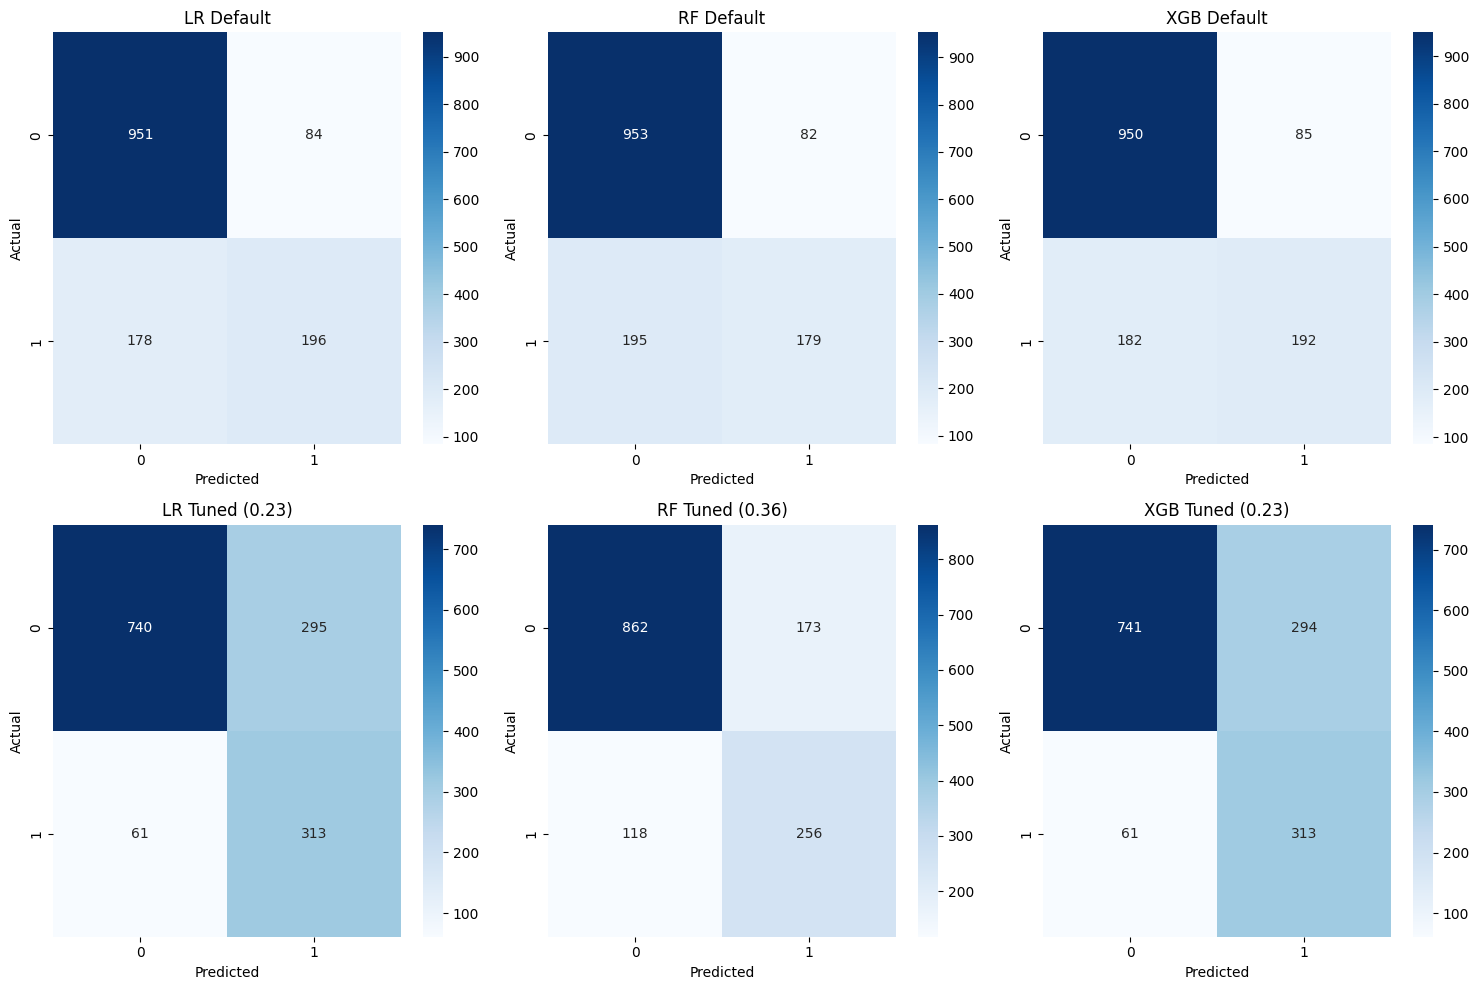

In [63]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

models = [
    ("LR Default", lr_model.predict(X_test)),
    ("RF Default", rf_model.predict(X_test)),
    ("XGB Default", xgb_model.predict(X_test)),
    (f"LR Tuned ({lr_threshold:.2f})", pred_lr_new_t),
    (f"RF Tuned ({rf_threshold:.2f})", pred_rf_new_t),
    (f"XGB Tuned ({xgb_threshold:.2f})", pred_xgb_new_t)
]

for ax, (title, preds) in zip(axes.flatten(), models):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## 8. PR curves

We plot Precision–Recall curves for all models.  
PR curves are more informative than ROC curves when the positive class (churn) is rare.

A model with a higher PR curve and higher PR-AUC is better at ranking churners above non-churners.



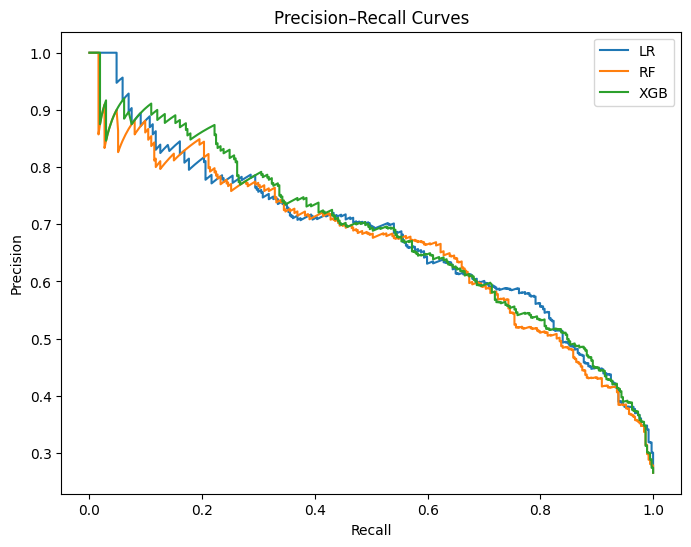

In [64]:
probas = [
    lr_model.predict_proba(X_test)[:, 1],
    rf_model.predict_proba(X_test)[:, 1],
    xgb_model.predict_proba(X_test)[:, 1]
]

names = ["LR", "RF", "XGB"]

plt.figure(figsize=(8,6))

for name, proba in zip(names, probas):
    precision, recall, _ = precision_recall_curve(y_test, proba)
    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves")
plt.legend()
plt.show()


## 9. Feature Importance

To understand what drives churn, we extract feature importance from all three models:

- **Logistic Regression**: coefficient magnitudes  
- **Random Forest**: impurity-based feature importance  
- **XGBoost**: gain-based importance from the booster  

We compare the top features across models to identify consistent churn drivers.  
This helps translate model outputs into actionable business insights.


In [65]:
feature_names = lr_model.named_steps["preprocessing"].get_feature_names_out()

lr_coeffs = lr_model.named_steps["clf"].coef_[0]
lr_df = pd.DataFrame({
    "feature": feature_names,
    "importance": lr_coeffs,
    "model": "Logistic Regression"
})

rf_estimator = rf_model.named_steps["rfc"]
rf_importances = rf_estimator.feature_importances_

rf_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_importances,
    "model": "Random Forest"
})

xgb_estimator = xgb_model.named_steps["xgb"]
booster = xgb_estimator.get_booster()
importance_dict = booster.get_score(importance_type="gain")

# Map f0, f1, ... to real feature names
xgb_importances = np.zeros(len(feature_names))
for key, value in importance_dict.items():
    idx = int(key[1:])
    xgb_importances[idx] = value

xgb_df = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_importances,
    "model": "XGBoost"
})

combined_df = pd.concat([lr_df, rf_df, xgb_df], axis=0)


In [66]:
top_n = 5

top_features = (
    combined_df.groupby("model")
    .apply(lambda x: x.nlargest(top_n, "importance"))
)

print(top_features)

                                                 feature  importance  \
model                                                                  
Logistic Regression 2                  num__TotalCharges    0.630923   
                    1                num__MonthlyCharges    0.490805   
                    30       remainder__PaperlessBilling    0.436839   
                    9       cat__Contract_Month-to-month    0.291430   
                    19          remainder__SeniorCitizen    0.198563   
Random Forest       0                        num__tenure    0.119235   
                    1                num__MonthlyCharges    0.105960   
                    9       cat__Contract_Month-to-month    0.101483   
                    2                  num__TotalCharges    0.101093   
                    3       num__ChargeTenureInteraction    0.098611   
XGBoost             9       cat__Contract_Month-to-month  162.822754   
                    7   cat__InternetService_Fiber optic   35.61

C:\Users\marle\AppData\Local\Temp\ipykernel_21200\3281110115.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(top_n, "importance"))


C:\Users\marle\AppData\Local\Temp\ipykernel_21200\2141373645.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(top_n, "importance"))


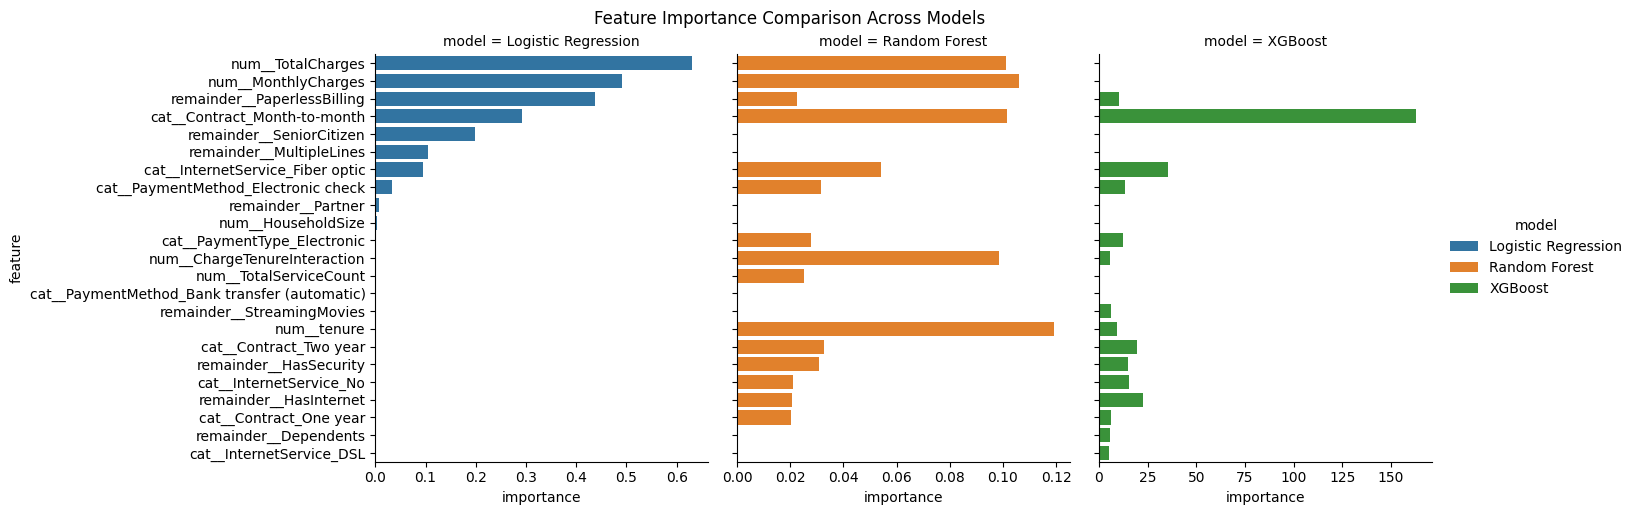

In [67]:
top_n = 15

top_features = (
    combined_df.groupby("model")
    .apply(lambda x: x.nlargest(top_n, "importance"))
    .reset_index(drop=True)
)

sns.catplot(
    data=top_features,
    x="importance",
    y="feature",
    hue="model",
    col="model",
    kind="bar",
    sharex=False,
    height=5,
    aspect=1
)

plt.suptitle("Feature Importance Comparison Across Models", y=1.02)
plt.show()


## 10. Model Comparison & Interpretation

Because the target variable *Churn* is highly imbalanced, accuracy is not a meaningful metric.  
Instead, we focus on:

- **Recall**: ability to correctly identify churners  
- **Precision**: how many predicted churners actually churn  
- **F1-score**: balance between precision and recall  
- **ROC-AUC**: ranking ability across thresholds  
- **PR-AUC**: more informative than ROC-AUC for imbalanced data  

### Key Observations

1. **Default thresholds (0.5)**  
   - Logistic Regression and XGBoost show similar performance.  
   - Recall is relatively low (~0.51), meaning many churners are missed.  
   - Precision is higher (~0.69–0.70), meaning predicted churners are more reliable.

2. **Tuned thresholds**  
   - Threshold optimization significantly increases recall (≈0.84).  
   - Precision drops (~0.51–0.52), which is expected because we classify more customers as churners.  
   - F1-score improves for all models, indicating a better balance.  
   - PR-AUC remains stable, confirming consistent ranking ability.

3. **Model comparison**  
   - XGBoost and Logistic Regression perform almost identically across all metrics.  
   - Random Forest performs slightly worse in both default and tuned settings.  
   - XGBoost shows the strongest feature importance signals, especially for contract type and internet service.


## 11. Final Model Selection

Given the business context of preventing customer churn, **recall is the most critical metric**, because missing a churner means losing a customer.

Based on the evaluation:

- **XGBoost with the tuned threshold** achieves the highest F1-score (0.638) and the highest recall (0.837).
- Logistic Regression with the tuned threshold performs nearly identically and is more interpretable.
- Random Forest performs slightly worse and is not selected.

### Final Choice
**XGBoost with the optimized threshold** is selected as the final model due to its strong recall, competitive F1-score, and ability to capture nonlinear relationships in the data.


## 12. Business Interpretation

The model identifies customers who are at high risk of churning.  
Using the tuned threshold:

- The model correctly identifies ~84% of churners.
- It also flags more customers as churners, which increases operational workload.
- However, this trade-off is acceptable because retaining a customer is typically more valuable than the cost of outreach.

### Key Drivers of Churn (from feature importance)

Across all models, the most influential features include:

- **Contract type (Month-to-month)** — strongest churn indicator.
- **Internet service type (Fiber optic)** — associated with higher churn.
- **TotalCharges and MonthlyCharges** — higher charges correlate with churn.
- **Tenure** — short-tenure customers are more likely to churn.
- **PaperlessBilling and SeniorCitizen** — moderate contributors.

These insights can guide targeted retention strategies:

- Offer discounts or incentives to month-to-month customers.
- Improve service quality for fiber-optic customers.
- Create onboarding programs for new customers with low tenure.


## 13. Next Steps

To further improve the churn prediction pipeline, the following steps are recommended:

1. **SMOTE or advanced resampling**  
   Test oversampling or hybrid methods to improve minority class representation.

2. **Cost-sensitive learning**  
   Incorporate business costs into the model (e.g., cost of false negatives vs. false positives).

3. **Model monitoring**  
   Deploy the model and track:
   - drift in feature distributions  
   - changes in churn behavior  
   - precision/recall over time  

4. **A/B testing**  
   Test retention interventions triggered by the model to measure real-world impact.

5. **Customer segmentation**  
   Combine churn risk with customer lifetime value (CLV) to prioritize outreach.
